## 04_luna_baseline_entrenamiento.ipynb
 Objetivo:
 1) entrenar un experto 3D baseline para LUNA16
 2) usar una arquitectura defendible y realista (R3D-18)
 3) incorporar AMP, early stopping y gradient checkpointing
 4) guardar checkpoint, history y métricas finales

## imports

In [1]:
from pathlib import Path
import json
import math
import time
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.checkpoint import checkpoint

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm.auto import tqdm

/home/luis_arcia/miniconda3/envs/tf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import SimpleITK as sitk
import scipy.ndimage as ndi

## configuración de entrenamiento

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path("/mnt/d/Universidad/analitica/proyecto_analitica2")
DATA_DIR = PROJECT_ROOT / "data"
MANIFESTS_DIR = DATA_DIR / "manifests"

MANIFEST_PATH = MANIFESTS_DIR / "manifest_luna16.csv"
SPLIT_PATH = MANIFESTS_DIR / "split_final_luna16.csv"

TARGET_SHAPE = (64, 64, 64)   # (D, H, W)
HU_MIN = -1000
HU_MAX = 400
TARGET_SPACING = (1.0, 1.0, 1.25)

BATCH_SIZE = 2
NUM_WORKERS = 0   # más estable en WSL; si todo va bien puedes subirlo luego a 2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("MANIFEST_PATH:", MANIFEST_PATH)
print("SPLIT_PATH:", SPLIT_PATH)
print("TARGET_SHAPE:", TARGET_SHAPE)
print("TARGET_SPACING:", TARGET_SPACING)


DEVICE: cuda
MANIFEST_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/manifest_luna16.csv
SPLIT_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/split_final_luna16.csv
TARGET_SHAPE: (64, 64, 64)
TARGET_SPACING: (1.0, 1.0, 1.25)


In [4]:
manifest = pd.read_csv(MANIFEST_PATH)
split_df = pd.read_csv(SPLIT_PATH)

df = manifest.merge(
    split_df[["seriesuid", "split"]],
    on="seriesuid",
    how="left"
)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

print("\nDistribución train:")
print(train_df["label_volume_binary"].value_counts())


train: (436, 15)
val: (93, 15)
test: (94, 15)

Distribución train:
label_volume_binary
1    300
0    136
Name: count, dtype: int64


## helpers de lectura y preprocesado

In [5]:
def read_ct_image(mhd_path):
    image = sitk.ReadImage(str(mhd_path))
    return image


def sanitize_hu_sitk(image, lower_bound=-1024):
    volume = sitk.GetArrayFromImage(image).astype(np.float32)  # [D, H, W]
    volume[volume < lower_bound] = lower_bound

    clean_image = sitk.GetImageFromArray(volume)
    clean_image.SetSpacing(image.GetSpacing())
    clean_image.SetOrigin(image.GetOrigin())
    clean_image.SetDirection(image.GetDirection())
    return clean_image


def resample_image_spacing(image, out_spacing=(1.0, 1.0, 1.25), is_label=False):
    original_spacing = image.GetSpacing()   # (x, y, z)
    original_size = image.GetSize()         # (x, y, z)

    out_size = [
        int(np.round(original_size[i] * (original_spacing[i] / out_spacing[i])))
        for i in range(3)
    ]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(image.GetDirection())
    resample.SetOutputOrigin(image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(float(-1024))

    if is_label:
        resample.SetInterpolator(sitk.sitkNearestNeighbor)
    else:
        resample.SetInterpolator(sitk.sitkLinear)

    return resample.Execute(image)


def clip_and_normalize_hu(volume, hu_min=HU_MIN, hu_max=HU_MAX):
    volume = np.clip(volume, hu_min, hu_max)
    volume = (volume - hu_min) / (hu_max - hu_min)
    volume = np.clip(volume, 0.0, 1.0)
    return volume.astype(np.float32)


def resize_volume_to_shape(volume, target_shape=TARGET_SHAPE, order=1):
    d, h, w = volume.shape
    td, th, tw = target_shape

    zoom_factors = (
        td / d,
        th / h,
        tw / w,
    )

    resized = ndi.zoom(volume, zoom=zoom_factors, order=order)
    return resized.astype(np.float32)


def preprocess_ct_from_path(
    mhd_path,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE,
    hu_min=HU_MIN,
    hu_max=HU_MAX,
):
    image = read_ct_image(mhd_path)
    image = sanitize_hu_sitk(image, lower_bound=-1024)
    image = resample_image_spacing(image, out_spacing=target_spacing, is_label=False)

    volume = sitk.GetArrayFromImage(image).astype(np.float32)  # [D, H, W]
    volume = clip_and_normalize_hu(volume, hu_min=hu_min, hu_max=hu_max)
    volume = resize_volume_to_shape(volume, target_shape=target_shape, order=1)

    return volume, image


## Dataset y DataLoaders

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path("/mnt/d/Universidad/analitica/proyecto_analitica2")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "luna16_r3d18_baseline_v2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HISTORY_PATH = OUTPUT_DIR / "history_luna16_r3d18_v2.csv"
BEST_MODEL_PATH = OUTPUT_DIR / "best_luna16_r3d18_v2.pt"
TEST_PRED_PATH = OUTPUT_DIR / "test_predictions_luna16_r3d18_v2.csv"
CONFIG_PATH = OUTPUT_DIR / "config_luna16_r3d18_v2.json"

NUM_CLASSES = 2
IN_CHANNELS = 1

EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
ACCUMULATION_STEPS = 2
GRAD_CLIP_NORM = 1.0

PATIENCE = 3
MIN_DELTA = 1e-4

USE_AMP = (DEVICE == "cuda")
USE_GRADIENT_CHECKPOINTING = True
USE_WEIGHTED_SAMPLER = False
USE_CLASS_WEIGHTS = True
USE_TRAIN_AUGMENT = True
AUG_NOISE_STD = 0.01

print("OUTPUT_DIR:", OUTPUT_DIR)
print("NUM_CLASSES:", NUM_CLASSES)
print("IN_CHANNELS:", IN_CHANNELS)
print("EPOCHS:", EPOCHS)
print("PATIENCE:", PATIENCE)
print("USE_AMP:", USE_AMP)
print("USE_GRADIENT_CHECKPOINTING:", USE_GRADIENT_CHECKPOINTING)
print("USE_WEIGHTED_SAMPLER:", USE_WEIGHTED_SAMPLER)
print("USE_CLASS_WEIGHTS:", USE_CLASS_WEIGHTS)
print("USE_TRAIN_AUGMENT:", USE_TRAIN_AUGMENT)


OUTPUT_DIR: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2
NUM_CLASSES: 2
IN_CHANNELS: 1
EPOCHS: 10
PATIENCE: 3
USE_AMP: True
USE_GRADIENT_CHECKPOINTING: True
USE_WEIGHTED_SAMPLER: False
USE_CLASS_WEIGHTS: True
USE_TRAIN_AUGMENT: True


In [7]:
def apply_train_augment_3d(volume, noise_std=0.01):
    # volume: numpy array [D, H, W] en [0, 1]
    if np.random.rand() < 0.5:
        volume = np.flip(volume, axis=2).copy()  # flip horizontal (W)

    if np.random.rand() < 0.5:
        volume = np.flip(volume, axis=1).copy()  # flip vertical (H)

    if np.random.rand() < 0.3:
        # rotación suave por slice en el plano H-W
        angle = np.random.uniform(-10.0, 10.0)
        volume = ndi.rotate(
            volume,
            angle=angle,
            axes=(1, 2),
            reshape=False,
            order=1,
            mode="nearest"
        ).astype(np.float32)

    if np.random.rand() < 0.3:
        noise = np.random.normal(0.0, noise_std, size=volume.shape).astype(np.float32)
        volume = volume + noise

    volume = np.clip(volume, 0.0, 1.0).astype(np.float32)
    return volume


class Luna16VolumeDataset(Dataset):
    def __init__(
        self,
        df,
        target_spacing=TARGET_SPACING,
        target_shape=TARGET_SHAPE,
        train_mode=False,
        use_augment=False,
        aug_noise_std=0.01
    ):
        self.df = df.reset_index(drop=True).copy()
        self.target_spacing = target_spacing
        self.target_shape = target_shape
        self.train_mode = train_mode
        self.use_augment = use_augment
        self.aug_noise_std = aug_noise_std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        volume, processed_image = preprocess_ct_from_path(
            row["mhd_path"],
            target_spacing=self.target_spacing,
            target_shape=self.target_shape,
            hu_min=HU_MIN,
            hu_max=HU_MAX,
        )

        if self.train_mode and self.use_augment:
            volume = apply_train_augment_3d(volume, noise_std=getattr(self, "aug_noise_std", 0.01))

        x = torch.from_numpy(volume).unsqueeze(0)  # [1, D, H, W]
        y = torch.tensor(int(row["label_volume_binary"]), dtype=torch.long)

        meta = {
            "seriesuid": row["seriesuid"],
            "subset": row["subset"],
            "split": row["split"],
            "mhd_path": row["mhd_path"],
            "processed_spacing_xyz": processed_image.GetSpacing(),
            "processed_size_xyz": processed_image.GetSize(),
        }

        return x, y, meta


def simple_collate(batch):
    xs, ys, metas = zip(*batch)
    xs = torch.stack(xs, dim=0)   # [B, 1, D, H, W]
    ys = torch.stack(ys, dim=0)   # [B]
    return xs, ys, metas


train_ds = Luna16VolumeDataset(
    train_df,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE,
    train_mode=True,
    use_augment=True,
    aug_noise_std=0.01
)
val_ds = Luna16VolumeDataset(
    val_df,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE,
    train_mode=False,
    use_augment=False
)
test_ds = Luna16VolumeDataset(
    test_df,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE,
    train_mode=False,
    use_augment=False
)

class_counts = train_df["label_volume_binary"].value_counts().sort_index().to_dict()
print("class_counts:", class_counts)

# pesos inversos por frecuencia ordenados por clase 0,1
class_weights_np = np.array(
    [1.0 / class_counts[c] for c in sorted(class_counts.keys())],
    dtype=np.float32
)
class_weights_np = class_weights_np / class_weights_np.sum() * len(class_weights_np)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)
print("class_weights:", class_weights)

if USE_WEIGHTED_SAMPLER:
    sample_weights = train_df["label_volume_binary"].map(
        lambda cls: 1.0 / class_counts[cls]
    ).values

    train_sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )
else:
    train_sampler = None

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=(train_sampler is None),
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

print("DataLoaders listos.")
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))


class_counts: {0: 136, 1: 300}
class_weights: tensor([1.3761, 0.6239], device='cuda:0')
DataLoaders listos.
Train size: 436
Val size: 93
Test size: 94


## guardar config

## modelo R3D-18 con 1 canal y checkpointing

In [8]:
import torchvision
from torchvision.models.video import r3d_18

In [9]:
class R3D18Binary(nn.Module):
    def __init__(self, num_classes=2, in_channels=1, use_gradient_checkpointing=True):
        super().__init__()
        self.use_gradient_checkpointing = use_gradient_checkpointing

        base = r3d_18(weights=None)

        old_conv = base.stem[0]
        new_conv = nn.Conv3d(
            in_channels=in_channels,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )

        nn.init.kaiming_normal_(new_conv.weight, mode="fan_out", nonlinearity="relu")
        base.stem[0] = new_conv
        base.fc = nn.Linear(base.fc.in_features, num_classes)

        self.base = base

    def _forward_features(self, x):
        x = self.base.stem(x)

        if self.training and self.use_gradient_checkpointing:
            x = checkpoint(self.base.layer1, x, use_reentrant=False)
            x = checkpoint(self.base.layer2, x, use_reentrant=False)
            x = checkpoint(self.base.layer3, x, use_reentrant=False)
            x = checkpoint(self.base.layer4, x, use_reentrant=False)
        else:
            x = self.base.layer1(x)
            x = self.base.layer2(x)
            x = self.base.layer3(x)
            x = self.base.layer4(x)

        x = self.base.avgpool(x)
        x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = self.base.fc(x)
        return x

## instanciar modelo

In [10]:
model = R3D18Binary(
    num_classes=NUM_CLASSES,
    in_channels=IN_CHANNELS,
    use_gradient_checkpointing=USE_GRADIENT_CHECKPOINTING
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model.__class__.__name__)
print(f"Parámetros totales: {n_params:,}")
print(f"Parámetros entrenables: {n_trainable:,}")

R3D18Binary
Parámetros totales: 33,148,482
Parámetros entrenables: 33,148,482


## loss, optimizer, scheduler, scaler

In [11]:
if USE_CLASS_WEIGHTS:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print("Loss, optimizer, scheduler y scaler listos.")


Loss, optimizer, scheduler y scaler listos.


## helpers de métricas

In [12]:
def compute_metrics(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
    }

## una época de entrenamiento

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, accumulation_steps=1):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(loader, desc="Train", leave=False)
    for step, (xb, yb, _) in enumerate(pbar, start=1):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(xb)
            loss = criterion(logits, yb)
            loss = loss / accumulation_steps

        scaler.scale(loss).backward()

        if step % accumulation_steps == 0 or step == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * accumulation_steps

        preds = torch.argmax(logits, dim=1)
        all_targets.extend(yb.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

        pbar.set_postfix({
            "loss": f"{running_loss / step:.4f}"
        })

    metrics = compute_metrics(all_targets, all_preds)
    metrics["loss"] = running_loss / len(loader)
    return metrics

## una época de validación/test

In [14]:
@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device, desc="Eval"):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_preds = []
    all_probs = []
    all_seriesuids = []

    pbar = tqdm(loader, desc=desc, leave=False)
    for xb, yb, metas in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(xb)
            loss = criterion(logits, yb)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        running_loss += loss.item()

        all_targets.extend(yb.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_probs.extend(probs[:, 1].detach().cpu().numpy().tolist())
        all_seriesuids.extend([m["seriesuid"] for m in metas])

        pbar.set_postfix({
            "loss": f"{running_loss / max(1, len(all_targets)):.4f}"
        })

    metrics = compute_metrics(all_targets, all_preds)
    metrics["loss"] = running_loss / len(loader)

    extra = {
        "targets": all_targets,
        "preds": all_preds,
        "probs_pos": all_probs,
        "seriesuids": all_seriesuids,
    }

    return metrics, extra

## early stopping

In [15]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return True

        improved = (
            score > self.best_score + self.min_delta
            if self.mode == "max"
            else score < self.best_score - self.min_delta
        )

        if improved:
            self.best_score = score
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False

## entrenamiento principal

In [16]:
history = []
best_state = None
best_epoch = -1
best_val_f1 = -np.inf

early_stopper = EarlyStopping(
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    mode="max"
)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE,
        accumulation_steps=ACCUMULATION_STEPS
    )

    val_metrics, _ = evaluate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        desc="Val"
    )

    scheduler.step(val_metrics["f1_macro"])

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "train_f1_macro": train_metrics["f1_macro"],
        "train_f1_micro": train_metrics["f1_micro"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_f1_macro": val_metrics["f1_macro"],
        "val_f1_micro": val_metrics["f1_micro"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"train_loss={row['train_loss']:.4f} | "
        f"train_f1_macro={row['train_f1_macro']:.4f} | "
        f"val_loss={row['val_loss']:.4f} | "
        f"val_f1_macro={row['val_f1_macro']:.4f}"
    )

    improved = early_stopper.step(val_metrics["f1_macro"])
    if improved:
        best_val_f1 = val_metrics["f1_macro"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, BEST_MODEL_PATH)
        print(f"Nuevo mejor modelo guardado en epoch {epoch} -> {BEST_MODEL_PATH}")

    if early_stopper.should_stop:
        print(f"Early stopping activado en epoch {epoch}")
        break

elapsed = time.time() - start_time
print(f"\nTiempo total de entrenamiento: {elapsed/60:.2f} min")
print("Best epoch:", best_epoch)
print("Best val_f1_macro:", round(best_val_f1, 4))


Epoch 1/10


train_loss=0.7212 | train_f1_macro=0.5030 | val_loss=0.9298 | val_f1_macro=0.3046
Nuevo mejor modelo guardado en epoch 1 -> /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/best_luna16_r3d18_v2.pt

Epoch 2/10


train_loss=0.7216 | train_f1_macro=0.4894 | val_loss=0.7359 | val_f1_macro=0.4283
Nuevo mejor modelo guardado en epoch 2 -> /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/best_luna16_r3d18_v2.pt

Epoch 3/10


train_loss=0.6992 | train_f1_macro=0.4815 | val_loss=0.6825 | val_f1_macro=0.4909
Nuevo mejor modelo guardado en epoch 3 -> /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/best_luna16_r3d18_v2.pt

Epoch 4/10


train_loss=0.7061 | train_f1_macro=0.5249 | val_loss=0.6362 | val_f1_macro=0.5832
Nuevo mejor modelo guardado en epoch 4 -> /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/best_luna16_r3d18_v2.pt

Epoch 5/10


train_loss=0.6767 | train_f1_macro=0.5058 | val_loss=0.6791 | val_f1_macro=0.4946

Epoch 6/10


train_loss=0.6824 | train_f1_macro=0.5571 | val_loss=0.6559 | val_f1_macro=0.4771

Epoch 7/10


train_loss=0.6717 | train_f1_macro=0.5123 | val_loss=0.6435 | val_f1_macro=0.5825
Early stopping activado en epoch 7

Tiempo total de entrenamiento: 103.78 min
Best epoch: 4
Best val_f1_macro: 0.5832


## guardar y mostrar history

In [17]:
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)

print("History guardado en:", HISTORY_PATH)
display(history_df.tail())

History guardado en: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/history_luna16_r3d18_v2.csv


,epoch,train_loss,train_acc,train_f1_macro,train_f1_micro,val_loss,val_acc,val_f1_macro,val_f1_micro,lr
2,3,0.699166,0.639908,0.481483,0.639908,0.682531,0.494624,0.490856,0.494624,0.00010
3,4,0.706095,0.633028,0.524899,0.633028,0.636219,0.698925,0.583227,0.698925,0.00010
4,5,0.676693,0.621560,0.505822,0.621560,0.679150,0.612903,0.494565,0.612903,0.00010
5,6,0.682446,0.655963,0.557091,0.655963,0.655898,0.666667,0.477054,0.666667,0.00010
6,7,0.671659,0.644495,0.512294,0.644495,0.643536,0.655914,0.582492,0.655914,0.00005


## curvas de entrenamiento

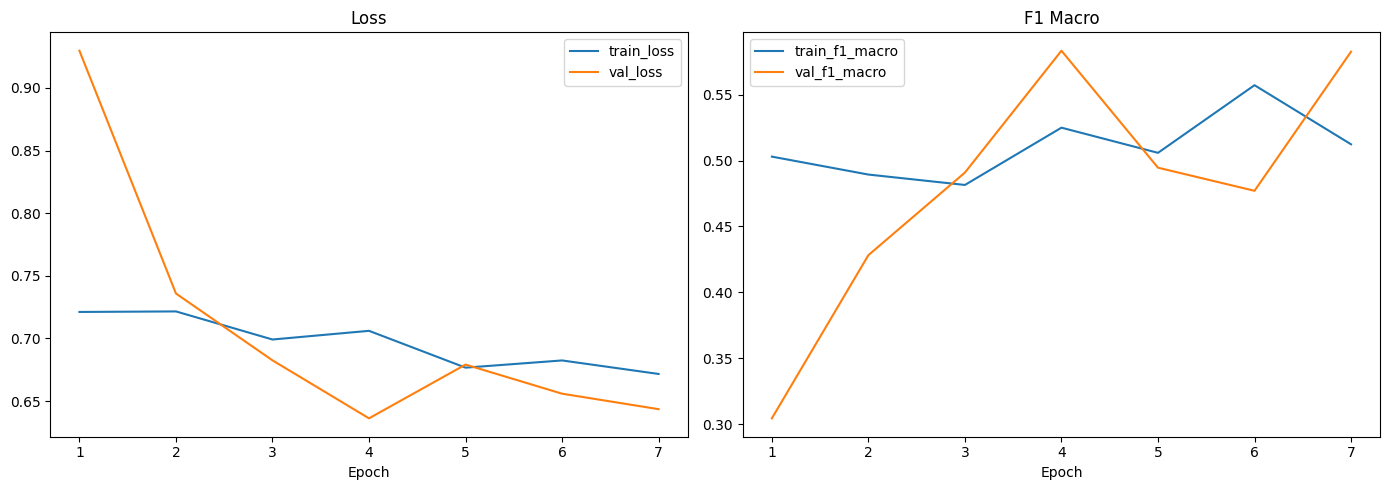

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_f1_macro"], label="train_f1_macro")
axes[1].plot(history_df["epoch"], history_df["val_f1_macro"], label="val_f1_macro")
axes[1].set_title("F1 Macro")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## cargar mejor checkpoint

In [19]:
best_state = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(best_state)
print("Mejor checkpoint cargado.")

Mejor checkpoint cargado.


In [26]:
# Reevaluar con el mejor checkpoint para asegurar que val_extra y test_extra estén actualizados
val_metrics, val_extra = evaluate_one_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=DEVICE,
    desc="Val threshold tuning"
)

test_metrics, test_extra = evaluate_one_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    desc="Test threshold tuning"
)

print("Validación base:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nTest base:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Validación base:
acc: 0.6989
f1_macro: 0.5832
f1_micro: 0.6989
loss: 0.6362

Test base:
acc: 0.6596
f1_macro: 0.5095
f1_micro: 0.6596
loss: 0.6578


In [27]:
def evaluate_threshold(y_true, prob_pos, threshold):
    y_pred = (np.array(prob_pos) >= threshold).astype(int)

    metrics = {
        "threshold": float(threshold),
        "acc": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_neg": f1_score(y_true, y_pred, pos_label=0, average="binary", zero_division=0),
        "f1_pos": f1_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0),
    }
    return metrics, y_pred

In [28]:
threshold_grid = np.round(np.arange(0.05, 0.96, 0.01), 2)

val_rows = []
for thr in threshold_grid:
    metrics_thr, _ = evaluate_threshold(
        y_true=val_extra["targets"],
        prob_pos=val_extra["probs_pos"],
        threshold=thr
    )
    val_rows.append(metrics_thr)

threshold_df = pd.DataFrame(val_rows).sort_values(
    by=["f1_macro", "f1_neg", "f1_pos"],
    ascending=False
).reset_index(drop=True)

display(threshold_df.head(10))

best_threshold = float(threshold_df.loc[0, "threshold"])
best_val_f1_macro_thr = float(threshold_df.loc[0, "f1_macro"])

print("Mejor threshold encontrado en validación:", best_threshold)
print("Mejor val_f1_macro con threshold tuning:", round(best_val_f1_macro_thr, 4))

,threshold,acc,f1_macro,f1_micro,f1_neg,f1_pos
0,0.56,0.688172,0.633211,0.688172,0.491228,0.775194
1,0.57,0.688172,0.633211,0.688172,0.491228,0.775194
2,0.51,0.720430,0.624534,0.720430,0.434783,0.814286
3,0.52,0.709677,0.615644,0.709677,0.425532,0.805755
4,0.53,0.709677,0.615644,0.709677,0.425532,0.805755
5,0.58,0.666667,0.615241,0.666667,0.474576,0.755906
6,0.55,0.677419,0.599598,0.677419,0.423077,0.776119
7,0.54,0.688172,0.598242,0.688172,0.408163,0.788321
8,0.48,0.731183,0.594453,0.731183,0.358974,0.829932
9,0.49,0.731183,0.594453,0.731183,0.358974,0.829932


Mejor threshold encontrado en validación: 0.56
Mejor val_f1_macro con threshold tuning: 0.6332


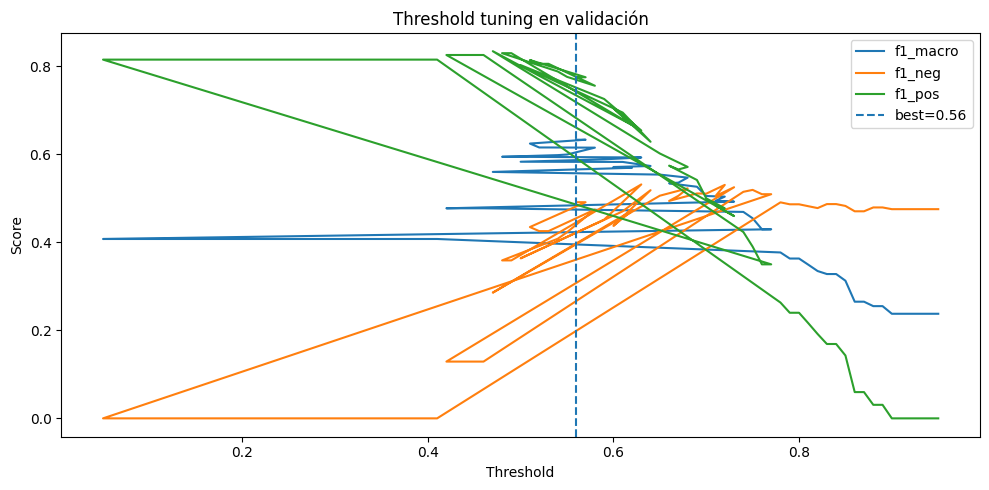

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["f1_macro"], label="f1_macro")
plt.plot(threshold_df["threshold"], threshold_df["f1_neg"], label="f1_neg")
plt.plot(threshold_df["threshold"], threshold_df["f1_pos"], label="f1_pos")
plt.axvline(best_threshold, linestyle="--", label=f"best={best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold tuning en validación")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
test_metrics_thr, test_pred_thr = evaluate_threshold(
    y_true=test_extra["targets"],
    prob_pos=test_extra["probs_pos"],
    threshold=best_threshold
)

print("Resultados en test con threshold tuning:")
for k, v in test_metrics_thr.items():
    if k != "threshold":
        print(f"{k}: {v:.4f}")
print("threshold usado:", best_threshold)

Resultados en test con threshold tuning:
acc: 0.6383
f1_macro: 0.5909
f1_micro: 0.6383
f1_neg: 0.4516
f1_pos: 0.7302
threshold usado: 0.56


In [31]:
print(
    classification_report(
        test_extra["targets"],
        test_pred_thr,
        target_names=["negativo", "positivo"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negativo       0.44      0.47      0.45        30
    positivo       0.74      0.72      0.73        64

    accuracy                           0.64        94
   macro avg       0.59      0.59      0.59        94
weighted avg       0.64      0.64      0.64        94



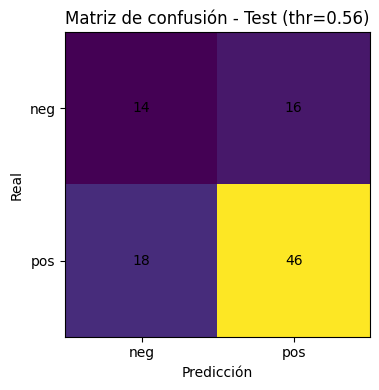

In [32]:
cm_thr = confusion_matrix(test_extra["targets"], test_pred_thr)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_thr)
ax.set_title(f"Matriz de confusión - Test (thr={best_threshold:.2f})")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["neg", "pos"])
ax.set_yticklabels(["neg", "pos"])

for i in range(cm_thr.shape[0]):
    for j in range(cm_thr.shape[1]):
        ax.text(j, i, cm_thr[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [33]:
TEST_PRED_THR_PATH = OUTPUT_DIR / "test_predictions_luna16_r3d18_threshold_tuned.csv"
THRESHOLD_SWEEP_PATH = OUTPUT_DIR / "val_threshold_sweep_luna16_r3d18.csv"

test_pred_thr_df = pd.DataFrame({
    "seriesuid": test_extra["seriesuids"],
    "y_true": test_extra["targets"],
    "prob_pos": test_extra["probs_pos"],
    "y_pred_threshold_tuned": test_pred_thr,
    "threshold_used": best_threshold,
})

test_pred_thr_df.to_csv(TEST_PRED_THR_PATH, index=False)
threshold_df.to_csv(THRESHOLD_SWEEP_PATH, index=False)

print("Guardado:")
print(" -", TEST_PRED_THR_PATH)
print(" -", THRESHOLD_SWEEP_PATH)

display(test_pred_thr_df.head())

Guardado:
 - /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/test_predictions_luna16_r3d18_threshold_tuned.csv
 - /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/val_threshold_sweep_luna16_r3d18.csv


,seriesuid,y_true,prob_pos,y_pred_threshold_tuned,threshold_used
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,1,0.561035,1,0.56
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.210837812047...,0,0.538574,0,0.56
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.231645134739...,0,0.714844,1,0.56
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.313334055029...,1,0.750488,1,0.56
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.975254950136...,0,0.677246,1,0.56


## evaluación final en validación

In [20]:
val_metrics, val_extra = evaluate_one_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=DEVICE,
    desc="Val final"
)

print("Resultados en validación:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

Resultados en validación:
acc: 0.6989
f1_macro: 0.5832
f1_micro: 0.6989
loss: 0.6362


## evaluación final en test

In [ ]:
comparison_df = pd.DataFrame([
    {
        "version": "base_argmax",
        "acc": test_metrics["acc"],
        "f1_macro": test_metrics["f1_macro"],
        "f1_micro": test_metrics["f1_micro"],
    },
    {
        "version": "threshold_tuned",
        "acc": test_metrics_thr["acc"],
        "f1_macro": test_metrics_thr["f1_macro"],
        "f1_micro": test_metrics_thr["f1_micro"],
    }
])

display(comparison_df)

In [21]:
test_metrics, test_extra = evaluate_one_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    desc="Test final"
)

print("Resultados en test:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Resultados en test:
acc: 0.6596
f1_macro: 0.5095
f1_micro: 0.6596
loss: 0.6578


## classification report test

In [22]:
print(
    classification_report(
        test_extra["targets"],
        test_extra["preds"],
        target_names=["negativo", "positivo"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negativo       0.42      0.17      0.24        30
    positivo       0.70      0.89      0.78        64

    accuracy                           0.66        94
   macro avg       0.56      0.53      0.51        94
weighted avg       0.61      0.66      0.61        94



## matriz de confusión test

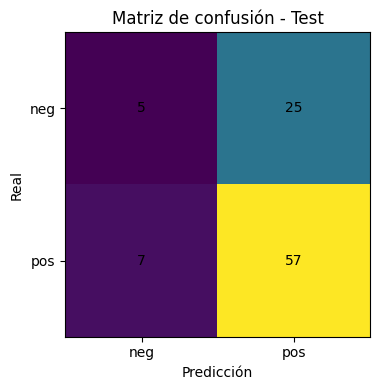

In [23]:
cm = confusion_matrix(test_extra["targets"], test_extra["preds"])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_title("Matriz de confusión - Test")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["neg", "pos"])
ax.set_yticklabels(["neg", "pos"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## guardar predicciones de test

In [24]:
test_pred_df = pd.DataFrame({
    "seriesuid": test_extra["seriesuids"],
    "y_true": test_extra["targets"],
    "y_pred": test_extra["preds"],
    "prob_pos": test_extra["probs_pos"],
})

test_pred_df.to_csv(TEST_PRED_PATH, index=False)
print("Predicciones de test guardadas en:", TEST_PRED_PATH)

display(test_pred_df.head())

Predicciones de test guardadas en: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/test_predictions_luna16_r3d18_v2.csv


,seriesuid,y_true,y_pred,prob_pos
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,1,1,0.561035
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.210837812047...,0,1,0.538574
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.231645134739...,0,1,0.714844
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.313334055029...,1,1,0.750488
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.975254950136...,0,1,0.677246


## resumen final del baseline

In [25]:
print("Resumen baseline LUNA16 - R3D18")
print("-" * 40)
print("Best epoch:", best_epoch)
print("Best val_f1_macro:", round(best_val_f1, 4))
print("Test loss:", round(test_metrics["loss"], 4))
print("Test acc:", round(test_metrics["acc"], 4))
print("Test f1_macro:", round(test_metrics["f1_macro"], 4))
print("Test f1_micro:", round(test_metrics["f1_micro"], 4))
print("Checkpoint:", BEST_MODEL_PATH)
print("History:", HISTORY_PATH)
print("Predicciones:", TEST_PRED_PATH)

Resumen baseline LUNA16 - R3D18
----------------------------------------
Best epoch: 4
Best val_f1_macro: 0.5832
Test loss: 0.6578
Test acc: 0.6596
Test f1_macro: 0.5095
Test f1_micro: 0.6596
Checkpoint: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/best_luna16_r3d18_v2.pt
History: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/history_luna16_r3d18_v2.csv
Predicciones: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/test_predictions_luna16_r3d18_v2.csv


In [35]:
FINAL_THRESHOLD = best_threshold
FINAL_TEST_ACC = test_metrics_thr["acc"]
FINAL_TEST_F1_MACRO = test_metrics_thr["f1_macro"]
FINAL_TEST_F1_MICRO = test_metrics_thr["f1_micro"]
FINAL_TEST_F1_NEG = test_metrics_thr["f1_neg"]
FINAL_TEST_F1_POS = test_metrics_thr["f1_pos"]

print("Resultado oficial provisional - LUNA16")
print("-" * 45)
print(f"threshold final: {FINAL_THRESHOLD:.2f}")
print(f"test_acc: {FINAL_TEST_ACC:.4f}")
print(f"test_f1_macro: {FINAL_TEST_F1_MACRO:.4f}")
print(f"test_f1_micro: {FINAL_TEST_F1_MICRO:.4f}")
print(f"test_f1_neg: {FINAL_TEST_F1_NEG:.4f}")
print(f"test_f1_pos: {FINAL_TEST_F1_POS:.4f}")

Resultado oficial provisional - LUNA16
---------------------------------------------
threshold final: 0.56
test_acc: 0.6383
test_f1_macro: 0.5909
test_f1_micro: 0.6383
test_f1_neg: 0.4516
test_f1_pos: 0.7302


In [36]:
FINAL_SUMMARY_PATH = OUTPUT_DIR / "final_summary_luna16_r3d18.csv"

final_summary_df = pd.DataFrame([{
    "model_name": "R3D18",
    "threshold_final": float(FINAL_THRESHOLD),
    "test_acc": float(FINAL_TEST_ACC),
    "test_f1_macro": float(FINAL_TEST_F1_MACRO),
    "test_f1_micro": float(FINAL_TEST_F1_MICRO),
    "test_f1_neg": float(FINAL_TEST_F1_NEG),
    "test_f1_pos": float(FINAL_TEST_F1_POS),
}])

final_summary_df.to_csv(FINAL_SUMMARY_PATH, index=False)
print("Resumen final guardado en:", FINAL_SUMMARY_PATH)
display(final_summary_df)

Resumen final guardado en: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/luna16_r3d18_baseline_v2/final_summary_luna16_r3d18.csv


,model_name,threshold_final,test_acc,test_f1_macro,test_f1_micro,test_f1_neg,test_f1_pos
0,R3D18,0.56,0.638298,0.590886,0.638298,0.451613,0.730159
